**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 2**
Pandas para el análisis de datos en Python

---

*   NOMBRE: Alejandra Edith Tobias Villa
*   MATRÍCULA: A01840886


---

En esta actividad trabajarás con el archivo `cleaned_weather.csv`, un extracto del conjunto de datos meteorológicos a lo largo de todo el año 2020 en una estación del Instituto *Max Planck* (Alemania) disponible en Kaggle.

Los datos meteorológicos fueron registrados cada 10 minutos e incluyen los siguientes indicadores:

*   `timestamp`: Fecha y hora de la observación.
*   `p`: Presión atmosférica en milibares (mbar)
*   `T`: Temperatura del aire en grados Celsius (°C)
*   `Tpot`: Temperatura potencial en Kelvin (K)
*   `rh`: Humedad relativa en porcentaje (%)
*   `VPact`: Presión real de vapor en milibares (mbar)
*   `sh`: Humedad específica en gramos por kilogramo (g/kg)
*   `H2OC`: Concentración de vapor de agua en milimoles por mol (mmol/mol) de aire seco
*   `rho`: Densidad del aire en gramos por metro cúbico (g/m³)
*   `wv`: Velocidad del viento en metros por segundo (m/s)
*   `wd`: Dirección del viento en grados (°)
*   `rain`: Precipitación total en milímetros (mm)
*   `raining`: Duración de la lluvia en segundos (s)

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.


In [32]:
# Importa las librerías necesarias
import pandas as pd
import numpy as np

1.	Descarga el archivo: `cleaned_weather.csv` y guarda, en un dataframe (`weather_df`), todos sus registros.
- Determina la dimensionalidad del dataframe y obtén los identificadores de columnas.
- Renombra las columnas para facilitar la interpretación de los indicadores en los ejercicios siguientes:
  - `medicion, presion_atmosferica, temperatura_celsius, temperatura_kelvin, humedad_relativa, presion_vapor, humedad_especifica, concentracion_vapor, densidad_aire, velocidad_viento, direccion_viento, precipitacion_total, duracion_lluvia`
- Muestra los primeros y los últimos 5 registros.

**- ¿Hay valores faltantes en el dataframe?**
No hay valores de tipo NaN en el dataframe.





In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/actividad2analisisPandas"
os.chdir(DIR)

In [35]:
#Guardar dataframe en weather_df
weather_df = pd.read_csv('cleaned_weather.csv')

#Determina dimensionalidad del df
print("Las dimensiones del dataframe son: ", weather_df.shape)

#Obtener los identificadores de columnas
print("Las columnas son: ", weather_df.columns)

#Renombrar columnas
weather_df.columns = ['medicion', 'presion_atmosferica', 'temperatura_celsius', 'temperatura_kelvin', 'humedad_relativa', 'presion_vapor', 'humedad_especifica', 'concentracion_vapor', 'densidad_aire', 'velocidad_viento', 'direccion_viento', 'precipitacion_total', 'duracion_lluvia']


Las dimensiones del dataframe son:  (52696, 13)
Las columnas son:  Index(['timestamp', 'p', 'T', 'Tpot', 'rh', 'VPact', 'sh', 'H2OC', 'rho', 'wv',
       'wd', 'rain', 'raining'],
      dtype='object')


In [36]:
#Mostrar primeros 5 registros
weather_df.head()

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
0,01/01/20 0:10,1008.89,0.71,273.18,86.1,5.54,3.42,5.49,1280.62,1.02,224.3,0.0,0
1,01/01/20 0:20,1008.76,0.75,273.22,85.2,5.49,3.39,5.45,1280.33,0.43,206.8,0.0,0
2,01/01/20 0:30,1008.66,0.73,273.21,85.1,5.48,3.39,5.43,1280.29,0.61,197.1,0.0,0
3,01/01/20 0:40,1008.64,0.37,272.86,86.3,5.41,3.35,5.37,1281.97,1.11,206.4,0.0,0
4,01/01/20 0:50,1008.61,0.33,272.82,87.4,5.47,3.38,5.42,1282.08,0.49,209.6,0.0,0


In [37]:
#Mostrr ultimos 5 registros
weather_df.tail()

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
52691,31/12/20 23:20,978.32,2.28,277.16,80.0,5.76,3.67,5.89,1234.61,0.73,180.6,0.0,0
52692,31/12/20 23:30,978.30,2.13,277.01,83.1,5.92,3.77,6.05,1235.20,0.43,174.0,0.0,0
52693,31/12/20 23:40,978.26,1.99,276.88,82.2,5.80,3.69,5.93,1235.82,0.38,248.9,0.0,0
52694,31/12/20 23:50,978.26,2.07,276.95,81.4,5.77,3.68,5.90,1235.49,0.57,196.6,0.0,0
52695,01/01/21 0:00,978.24,2.01,276.89,82.4,5.82,3.71,5.95,1235.71,0.57,221.3,0.0,0


In [38]:
#Determinar si hay valores faltantes en el dataframe
weather_df.isna().values.any()

np.False_

2. Determina el tipo de datos que tienen las columnas.
- Cambia la columna `medicion` a datetime utilizando el formato: `%d/%m/%y %H:%M`
- Obtén dos columnas adicionales separando `medicion` en `fecha` y `hora`

In [39]:
#Tipo de datos de las columnas
weather_df.dtypes

,0
medicion,object
presion_atmosferica,float64
temperatura_celsius,float64
temperatura_kelvin,float64
humedad_relativa,float64
presion_vapor,float64
humedad_especifica,float64
concentracion_vapor,float64
densidad_aire,float64
velocidad_viento,float64


In [40]:
#Cambiar columna medicion a datetime
weather_df['medicion'] = pd.to_datetime(weather_df['medicion'], format='%d/%m/%y %H:%M')

#Split medicion para mostrar hora y fecha separado
weather_df['medicion_fecha'] = weather_df['medicion'].dt.normalize()
weather_df['medicion_hora'] = weather_df['medicion'].dt.time

weather_df.head()

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,medicion_fecha,medicion_hora
0,2020-01-01 00:10:00,1008.89,0.71,273.18,86.1,5.54,3.42,5.49,1280.62,1.02,224.3,0.0,0,2020-01-01,00:10:00
1,2020-01-01 00:20:00,1008.76,0.75,273.22,85.2,5.49,3.39,5.45,1280.33,0.43,206.8,0.0,0,2020-01-01,00:20:00
2,2020-01-01 00:30:00,1008.66,0.73,273.21,85.1,5.48,3.39,5.43,1280.29,0.61,197.1,0.0,0,2020-01-01,00:30:00
3,2020-01-01 00:40:00,1008.64,0.37,272.86,86.3,5.41,3.35,5.37,1281.97,1.11,206.4,0.0,0,2020-01-01,00:40:00
4,2020-01-01 00:50:00,1008.61,0.33,272.82,87.4,5.47,3.38,5.42,1282.08,0.49,209.6,0.0,0,2020-01-01,00:50:00


3. Determina la cantidad de valores únicos de cada columna.
- La columna `medicion` tiene un valor menos que el número total de filas del dataframe, lo que indica que hay una fecha duplicada. Identifica cuál es.
- Comprueba si las demás columnas también contienen los mismos valores; si es así, elimina  uno de los registros duplicados.


In [41]:
#Cantidad de valores unicos de cada columna
weather_df.nunique()

,0
medicion,52695
presion_atmosferica,5052
temperatura_celsius,3680
temperatura_kelvin,3836
humedad_relativa,5494
presion_vapor,2059
humedad_especifica,1337
concentracion_vapor,2087
densidad_aire,14826
velocidad_viento,977


In [42]:
#Encontrar valor duplicado en medicion
weather_df[weather_df['medicion'].duplicated(keep=False)]

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,medicion_fecha,medicion_hora
19043,2020-05-12 06:00:00,991.53,-1.57,272.25,96.2,5.24,3.29,5.28,1269.29,1.04,215.4,0.0,0,2020-05-12,06:00:00
19044,2020-05-12 06:00:00,991.53,-1.57,272.25,96.2,5.24,3.29,5.28,1269.29,1.04,215.4,0.0,0,2020-05-12,06:00:00


In [43]:
#Eliminar el duplicado
weather_df = weather_df.drop_duplicates(subset=['medicion'], keep='first')
#weather_df = weather_df.drop(index=19044)

4. Imprime nuevamente las cantidad de valores únicos por columna.

**- ¿Por qué son 144 horas diferentes?**
La columna medicion_hora contiene 144 valores únicos debido a que las mediciones se realizan en intervalos de 10 minutos.

Considerando que un día tiene 1,440 minutos, al dividir este periodo en intervalos de 10 minutos se obtienen 144 intervalos de medición diferentes.

- La cantidad de combinaciones únicas de fecha y hora no coincide con el número total de mediciones. Aunque no haya valores NaN, esto no garantiza que no se hayan omitido registros. Identifica las fechas en las que faltan mediciones.
- Una vez concluido el análisis de mediciones faltantes, elimina todos los registros que no correspondan al año 2020 y la columna `medicion`.


In [44]:
#Cantidad de valores unicos de cada columna
weather_df.nunique()

,0
medicion,52695
presion_atmosferica,5052
temperatura_celsius,3680
temperatura_kelvin,3836
humedad_relativa,5494
presion_vapor,2059
humedad_especifica,1337
concentracion_vapor,2087
densidad_aire,14826
velocidad_viento,977


In [45]:
#Se hace un agrupamiento de cantidad de registros por fecha
registros_por_fecha = weather_df.groupby('medicion_fecha').size()

#Se obtienen las fechas que no se tomaron los 144 registros
registros_por_fecha[registros_por_fecha < 144]

,0
medicion_fecha,
2020-01-01,143
2020-05-29,135
2021-01-01,1


En base al output de la celda, se puede observar que son 3 fechas en las que faltaron mediciones.

Esto se sabe porque las mediciones se tomaron de forma diaria, cada 10 minutos, por lo que por día se debería contar con 144 mediciones. Sin embargo, en estas fechas se puede observar que la cantidad es menor.

In [46]:
#Eliminar registros que no sean del año 2020
weather_df = weather_df[
    weather_df['medicion_fecha'].dt.year == 2020
]

#Eliminar columna medicion
weather_df = weather_df.drop(columns=['medicion'])

In [47]:
weather_df.shape

(52694, 14)

5. Obtén un dataframe `indicadores_diarios` que sólo almacene el mayor valor de las mediciones por fecha para responder:

**- ¿Cuál fue la máxima precipitación y a qué fecha pertenece?**
La máxima precipitación fue 11.2 y pertenece a la fecha de 2020-06-16

**- ¿Cuáles fueron los tres días con las velocidades de viento más altas registradas?**
Los 3 días con las velocidades de viento más altas fueron el 10/02, 16/02 y 09/02 en el año 2020.

**- ¿Cuántos días rebasaron el 90% de humedad relativa y los 30° celsius?**
5 días

In [48]:
#Obtener dataframe que almacene el mayor valor de las mediciones por fecha.
indicadores_diarios = weather_df.groupby('medicion_fecha').max(numeric_only=True)
indicadores_diarios.head()

,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
medicion_fecha,,,,,,,,,,,,
2020-01-01,1008.89,4.58,277.27,95.0,5.81,3.60,5.77,1298.02,1.91,356.9,0.0,0
2020-01-02,1004.16,6.47,279.72,93.9,5.57,3.48,5.58,1304.37,2.67,358.8,0.0,0
2020-01-03,998.45,8.17,281.80,89.3,9.34,5.86,9.39,1266.97,8.79,336.5,0.2,470
2020-01-04,1003.47,6.61,280.15,91.4,8.54,5.36,8.58,1270.10,4.61,354.7,1.0,600
2020-01-05,1009.07,4.43,277.01,85.3,6.44,3.99,6.40,1275.47,3.14,274.6,0.0,0


In [49]:
#Ordernar los datos de mayor a menor para obtener el top 1 y así obtener el dato de la fecha con mayor precipitación
indicadores_diarios.sort_values('precipitacion_total', ascending=False).head(1)

,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
medicion_fecha,,,,,,,,,,,,
2020-06-16,990.12,23.86,298.08,97.9,18.56,11.78,18.81,1188.93,4.39,353.8,11.2,600


In [50]:
#Ordenar de mayor a menor para obtener las top 3 velocidades más altas de viento.
indicadores_diarios.sort_values(
    "velocidad_viento",
    ascending=False
).head(3)

,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
medicion_fecha,,,,,,,,,,,,
2020-02-10,975.67,12.41,288.42,90.70,10.52,6.82,10.91,1232.13,13.77,350.3,2.5,600
2020-02-16,990.38,17.16,292.13,65.57,8.63,5.47,8.76,1222.82,13.00,214.6,0.2,50
2020-02-09,995.88,12.68,288.39,74.40,8.13,5.14,8.25,1246.67,12.52,268.6,0.0,0


In [51]:
#Consultar la cantidad de dias con la humedad mayor a 90% y temperatura mayor a 30 grados celsius.
dias = len(indicadores_diarios[(indicadores_diarios['humedad_relativa']>90) & (indicadores_diarios['temperatura_celsius'] > 30)])
print(dias)

5


6. La función `describe()` resume múltiples estadísticas descriptivas. Utiliza esta función para explorar y responder las preguntas sobre las variables en el dataframe de `indicadores_diarios `:

**- ¿Cuál es la desviación estándar de la concentración de vapor y qué indica?**
   La desviación estándar es de *4.573267*. Esto indica qué tanto se dispersan los puntos de medición con respecto al promedio.

**- ¿Cuál es la mediana de la presión atmosférica y qué significa?** La mediana de la presión atmosférica es *993.3*. Esto significa que el 50% de las mediciones registradas en el año son menores a 993.3 mbar.

**- ¿Cuál es el tercer cuartil de la duración de la lluvia y cómo se interpreta?** El tercer cuartil de la duración de la lluvia es *600*. Esto se interpreta como que el 75% de los datos en las mediciones son menores a 600 segundos. Esto significa que en el año 2020 la mayor parte de la lluvia no duro más de 10 minutos.

In [52]:
indicadores_diarios.describe()

,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,992.977842,15.343770,289.431667,90.886530,11.409454,7.214016,11.539180,1232.622814,5.245164,317.673689,0.314208,240.382514
std,8.543447,7.850339,7.942175,9.201588,4.507555,2.872647,4.573267,32.702446,2.097012,50.611324,0.979721,273.840002
min,959.900000,-0.120000,273.460000,55.440000,3.320000,2.050000,3.290000,1167.050000,1.570000,69.570000,0.000000,0.000000
25%,988.015000,8.840000,282.732500,85.400000,7.647500,4.832500,7.742500,1207.590000,3.662500,279.075000,0.000000,0.000000
50%,993.300000,15.060000,289.160000,93.250000,10.715000,6.705000,10.735000,1231.455000,4.880000,346.650000,0.000000,0.000000
75%,998.432500,21.695000,295.957500,99.900000,14.462500,9.180000,14.685000,1256.057500,6.495000,357.300000,0.200000,600.000000
max,1020.070000,34.800000,309.130000,100.000000,24.160000,15.400000,24.530000,1318.520000,13.770000,360.000000,11.200000,600.000000


7.	Dibuja un histograma para cada una de las columnas de `indicadores_diarios`.

array([[<Axes: title={'center': 'presion_atmosferica'}>,
        <Axes: title={'center': 'temperatura_celsius'}>,
        <Axes: title={'center': 'temperatura_kelvin'}>],
       [<Axes: title={'center': 'humedad_relativa'}>,
        <Axes: title={'center': 'presion_vapor'}>,
        <Axes: title={'center': 'humedad_especifica'}>],
       [<Axes: title={'center': 'concentracion_vapor'}>,
        <Axes: title={'center': 'densidad_aire'}>,
        <Axes: title={'center': 'velocidad_viento'}>],
       [<Axes: title={'center': 'direccion_viento'}>,
        <Axes: title={'center': 'precipitacion_total'}>,
        <Axes: title={'center': 'duracion_lluvia'}>]], dtype=object)

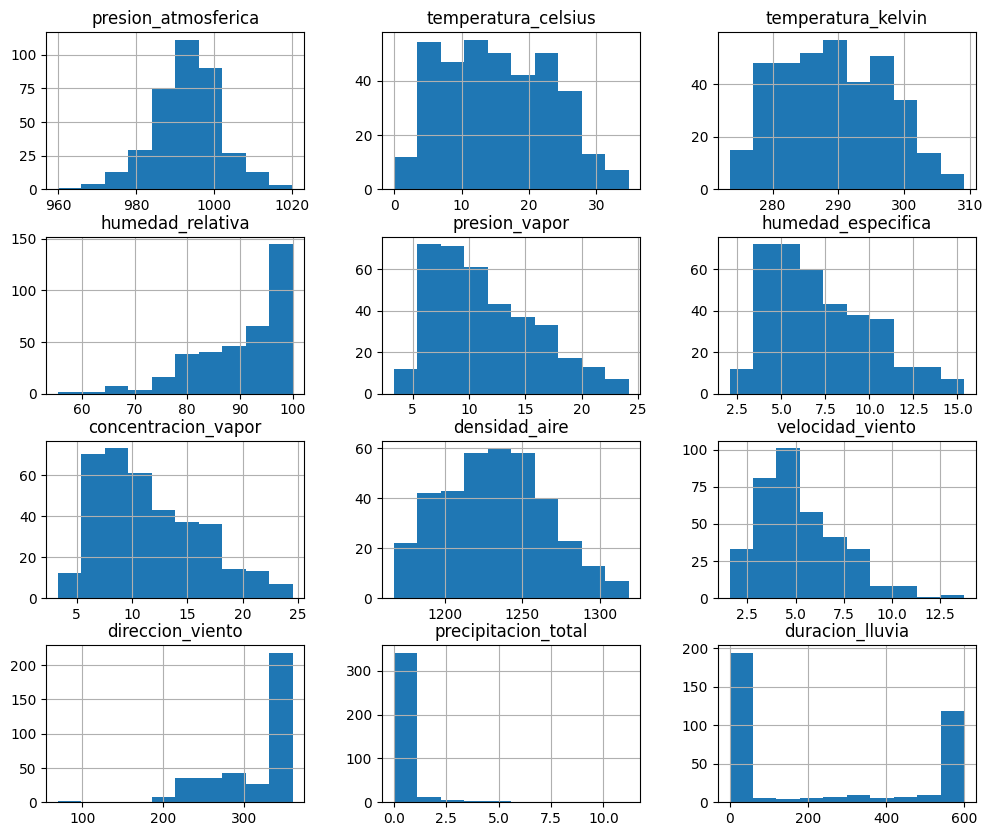

In [53]:
indicadores_diarios.hist(figsize=(12,10))

8. Utiliza el dataframe de indicadores diarios para crear un nuevo dataframe `indicadores_mensuales`. Para ello:
- Crea una nueva columna `mes` a partir de la fecha que se encuentra en el índice.
- Haciendo uso de `groupby()`, calcula los promedios mensuales y conserva únicamente las columnas `humedad_relativa`, `temperatura_celsius` y `velocidad_viento` en el nuevo dataframe.

In [54]:
#Crear nuevo dataframe a partir de indicadores_diarios.
indicadores_mensuales = indicadores_diarios.copy()

#Crear nueva columna "mes"
indicadores_mensuales["mes"] = indicadores_mensuales.index.month
indicadores_mensuales.head()

,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,mes
medicion_fecha,,,,,,,,,,,,,
2020-01-01,1008.89,4.58,277.27,95.0,5.81,3.60,5.77,1298.02,1.91,356.9,0.0,0,1
2020-01-02,1004.16,6.47,279.72,93.9,5.57,3.48,5.58,1304.37,2.67,358.8,0.0,0,1
2020-01-03,998.45,8.17,281.80,89.3,9.34,5.86,9.39,1266.97,8.79,336.5,0.2,470,1
2020-01-04,1003.47,6.61,280.15,91.4,8.54,5.36,8.58,1270.10,4.61,354.7,1.0,600,1
2020-01-05,1009.07,4.43,277.01,85.3,6.44,3.99,6.40,1275.47,3.14,274.6,0.0,0,1


In [55]:
#Calcular promedio mensuales
indicadores_mensuales = indicadores_mensuales[['mes', 'humedad_relativa', 'temperatura_celsius', 'velocidad_viento']]
indicadores_mensuales.head()

indicadores_mensuales.groupby('mes').mean()

,humedad_relativa,temperatura_celsius,velocidad_viento
mes,,,
1,89.776129,6.821290,5.031935
2,85.719655,8.962414,7.489655
3,85.372903,9.683871,6.421290
4,80.938667,16.879667,4.997000
5,87.464839,17.135484,4.865806
6,94.256000,22.212000,5.296667
7,85.959355,24.336129,4.830323
8,92.002581,26.097742,5.040323
9,97.570000,21.571667,4.153333


9. Construye el mismo dataframe mensual, pero esta vez utilizando la función `pivot_table()`.
- Añade la columna `indice_calor` usando la fórmula de Thom (*Temperature - Humidity Index*, TDI):
> `temperatura_celsius + 0.33 x humedad_relativa - 0.7 x velocidad_viento - 4`

In [56]:
indicadores_mensuales = indicadores_diarios.copy()
indicadores_mensuales["mes"] = indicadores_mensuales.index.month

#Dataframe mensual utilizando la funcion pivot_table()
indicadores_mensuales = (
    indicadores_mensuales
    .pivot_table(
        index="mes",
        values=[
            "humedad_relativa",
            "temperatura_celsius",
            "velocidad_viento"
        ],
        aggfunc="mean"
    )
)

indicadores_mensuales["indice_calor"] = (
    indicadores_mensuales["temperatura_celsius"]
    + 0.33 * indicadores_mensuales["humedad_relativa"]
    - 0.7 * indicadores_mensuales["velocidad_viento"]
    - 4
)

indicadores_mensuales

,humedad_relativa,temperatura_celsius,velocidad_viento,indice_calor
mes,,,,
1,89.776129,6.821290,5.031935,28.925058
2,85.719655,8.962414,7.489655,28.007141
3,85.372903,9.683871,6.421290,29.362026
4,80.938667,16.879667,4.997000,36.091527
5,87.464839,17.135484,4.865806,38.592816
6,94.256000,22.212000,5.296667,45.608813
7,85.959355,24.336129,4.830323,45.321490
8,92.002581,26.097742,5.040323,48.930368
9,97.570000,21.571667,4.153333,46.862433


10. Recuerda que de las cuatro funciones estudiadas para manipular la estructura del dataframe:
- `melt/pivot` hacen las transformaciones de manera controlada, es decir puedes
definir por medio de sus parámetros qué variables quedarán como índices, columnas y valores.
- `stack/unstack` la conversión se aplica siempre sobre los niveles inferiores de index/columns.
- Convierte el dataframe del ejercicio anterior a formato largo usando: `melt()` y `stack()` y comenta las diferencias.

In [57]:
indicadores_mensuales_long_melt = indicadores_mensuales.reset_index().melt(
    id_vars = 'mes',
    var_name = 'parámetro',
    value_name = 'medicion'
)

indicadores_mensuales_long_melt

,mes,parámetro,medicion
0,1,humedad_relativa,89.776129
1,2,humedad_relativa,85.719655
2,3,humedad_relativa,85.372903
3,4,humedad_relativa,80.938667
4,5,humedad_relativa,87.464839
5,6,humedad_relativa,94.256000
6,7,humedad_relativa,85.959355
7,8,humedad_relativa,92.002581
8,9,humedad_relativa,97.570000
9,10,humedad_relativa,96.950645


In [58]:
indicadores_mensuales_long_stack = indicadores_mensuales.stack()

indicadores_mensuales_long_stack

mes                     
1    humedad_relativa       89.776129
     temperatura_celsius     6.821290
     velocidad_viento        5.031935
     indice_calor           28.925058
2    humedad_relativa       85.719655
     temperatura_celsius     8.962414
     velocidad_viento        7.489655
     indice_calor           28.007141
3    humedad_relativa       85.372903
     temperatura_celsius     9.683871
     velocidad_viento        6.421290
     indice_calor           29.362026
4    humedad_relativa       80.938667
     temperatura_celsius    16.879667
     velocidad_viento        4.997000
     indice_calor           36.091527
5    humedad_relativa       87.464839
     temperatura_celsius    17.135484
     velocidad_viento        4.865806
     indice_calor           38.592816
6    humedad_relativa       94.256000
     temperatura_celsius    22.212000
     velocidad_viento        5.296667
     indice_calor           45.608813
7    humedad_relativa       85.959355
     temperatura_celsius    24.336129
     velocidad_viento        4.830323
     indice_calor           45.321490
8    humedad_relativa       92.002581
     temperatura_celsius    26.097742
     velocidad_viento        5.040323
     indice_calor           48.930368
9    humedad_relativa       97.570000
     temperatura_celsius    21.571667
     velocidad_viento        4.153333
     indice_calor           46.862433
10   humedad_relativa       96.950645
     temperatura_celsius    14.089355
     velocidad_viento        5.675484
     indice_calor           38.110229
11   humedad_relativa       96.983333
     temperatura_celsius    10.561667
     velocidad_viento        4.399000
     indice_calor           35.486867
12   humedad_relativa       97.510968
     temperatura_celsius     5.680000
     velocidad_viento        4.817097
     indice_calor           30.486652
dtype: float64

---

**Declaración de uso de IA**

*   OpenAI. (2026). *ChatGPT (basado en GPT-4)* GPT-5.6 Luna, utilizado para generación de código y depuración. https://chat.openai.com/

---